# Лабораторная работа №1.1: Первичное исследование и оценка качества данных

In [1]:
import pandas as pd
from datetime import date
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/vgsales.csv')

## 1) Типы признаков и шкалы измерения

### Задание 1.

In [11]:
print('Типы шкал измерения для каждого признака:')

print('Rank        : порядковая')
print('Name        : номинальная')
print('Platform    : номинальная')
print('Year        : интервальная')
print('Genre       : номинальная')
print('Publisher   : номинальная')
print('NA_Sales    : абсолютная')
print('EU_Sales    : абсолютная')
print('JP_Sales    : абсолютная')
print('Other_Sales : абсолютная')
print('Global_Sales: абсолютная')
print()

print('Анализ двух признаков с разными шкалами:')
print()

print('Global_Sales (абсолютная):')
print(f'Среднее: ', df['Global_Sales'].mean().round(4))
print(f'Медиана: ', df['Global_Sales'].median())
print(f'Мода: ', df['Global_Sales'].mode().values[0])
print()

print('Platform (номинальная):')
print('Среднее: Нет')
print('Медиана: Нет')
print(f'Мода:', df['Platform'].mode().values[0])
print()

print('Вывод: Для номинальных признаков, таких как Platform, считать можно только моду (самое частое значение). Среднее и медиану считать методологически неверно')


Типы шкал измерения для каждого признака:
Rank        : абсолютная
Name        : номинальная
Platform    : номинальная
Year        : интервальная
Genre       : номинальная
Publisher   : номинальная
NA_Sales    : абсолютная
EU_Sales    : абсолютная
JP_Sales    : абсолютная
Other_Sales : абсолютная
Global_Sales: абсолютная

Анализ двух признаков с разными шкалами:

Global_Sales:
Среднее:  0.5396
Медиана:  0.17
Мода:  0.02

Platform:
Среднее: Нет
Медиана: Нет
Мода: DS

Вывод: Для номинальных признаков, таких как Platform, считать можно только моду (самое частое значение). Среднее и медиану считать методологически неверно


## 2)  Пропуски и их природа (MCAR / MAR / MNAR)

### Задание 2. Диагностика типа пропусков

In [6]:
print('Выберем признак с пропусками - Year (271 пропусков, 1.63%)')
print('Количество пропусков:', df['Year'].isnull().sum())
print('Процент пропусков:', ((df['Year'].isnull().sum() / df.shape[0] * 100)).round(2))
print()

print('Гипотеза 1: Пропуски - MCAR (Случайно)')
print('  Нет корреляции с другими признаками. Пропуски случайны.')
print('Гипотеза 2: Пропуски - MAR (Зависит от других наблюдаемых признаков)')
print('  Связаны с Platform, Genre, Publisher или низкими продажами.')
print('Гипотеза 3: Пропуски - MNAR (Зависит от самого Year)')
print('  Старые игры имеют меньше данных о годе выпуска.')
print()

print('Проверки гипотез: сравниваем признаки с пропусками vs без пропусков')

missing_year = df['Year'].isnull()

print('Средние продаж Global_Sales:')
print(f'С пропусками Year: {df[missing_year]["Global_Sales"].mean():.3f}')
print(f'Без пропусков Year: {df[~missing_year]["Global_Sales"].mean():.3f}')

print('\nСравнение по всем платформам')
platform_freq_missing = df[missing_year]['Platform'].value_counts()
platform_freq_all = df['Platform'].value_counts()

top_platforms = platform_freq_all.head(10).index
for platform in top_platforms:
    count_missing = platform_freq_missing.get(platform, 0)
    count_all = platform_freq_all[platform]
    share_missing = (count_missing / count_all * 100).round(1)
    if share_missing > 1.0:  # Если >1% от общего по платформе
        print(f'{platform}: {count_missing} пропусков ({share_missing}%) из {count_all} игр')

print('\nСравнение по всем жанрам')
genre_freq_missing = df[missing_year]['Genre'].value_counts()
genre_freq_all = df['Genre'].value_counts()

top_genres = genre_freq_all.head(10).index
for genre in top_genres:
    count_missing = genre_freq_missing.get(genre, 0)
    count_all = genre_freq_all[genre]
    share_missing = (count_missing / count_all * 100).round(1)
    if share_missing > 1.0:
        print(f'{genre}: {count_missing} пропусков ({share_missing}%) из {count_all} игр')


print('\nСреднее количество продаж всех игр с значительно ниже всех чем игр без пропусков. Количество пропусков равномерно коррелирует с общим количеством игр на платформе, а также с количеством игр в жанре. \nВывод: чем хуже продалась игра, тем больше пропусков в поле Year, а значит пропуски, предположительно, - MAR')

Выберем признак с пропусками - Year (271 пропусков, 1.63%)
Количество пропусков: 271
Процент пропусков: 1.63

Гипотеза 1: Пропуски - MCAR (Случайно)
  Нет корреляции с другими признаками. Пропуски случайны.
Гипотеза 2: Пропуски - MAR (Зависит от других наблюдаемых признаков)
  Связаны с Platform, Genre, Publisher или низкими продажами.
Гипотеза 3: Пропуски - MNAR (Зависит от самого Year)
  Старые игры имеют меньше данных о годе выпуска.

Проверки гипотез: сравниваем признаки с пропусками vs без пропусков
Средние продаж Global_Sales:
С пропусками Year: 0.369
Без пропусков Year: 0.542

Сравнение по всем платформам
DS: 30 пропусков (1.4%) из 2164 игр
PS2: 34 пропусков (1.6%) из 2163 игр
PS3: 25 пропусков (1.9%) из 1329 игр
Wii: 35 пропусков (2.6%) из 1326 игр
X360: 30 пропусков (2.4%) из 1265 игр
PSP: 16 пропусков (1.3%) из 1213 игр
PC: 17 пропусков (1.8%) из 960 игр
XB: 21 пропусков (2.5%) из 824 игр
GBA: 11 пропусков (1.3%) из 822 игр

Сравнение по всем жанрам
Action: 63 пропусков (1.9%

### Задание 3. Индикатор пропуска как источник информации

1) Пропуск несёт информацию, когда он не случаен и связан с другими характеристиками объекта, т.е. пропуск — MAR.

2) Значимость индикатора в модели показывает, что простое заполнение медианой
не уловило закономерности. Модель использует факт пропуска, а не заполненное значение Year. Это сигнал улучшить импутацию.

3) Примеры признаков для индикатора пропуска:
• Полезен: Year — сигнализирует о низких продажах
• Бесполезен: Publisher при случайных опечатках — не коррелирует с продажами
• Опасен: NA_Sales — означает "игра не продавалась в США", что создаёт утечку информации о провале на рынке

## 3)  Выбросы

### Задание 4. Выброс - это ошибка или сигнал?

Выбранный признак: Global_Sales = 82.90 млн копий (игра Wii Sports)

1. Реальные причины значения
Значение объясняется бизнес-контекстом:
Wii Sports поставлялась в комплекте с консолью Wii
Пик популярности Wii (2006-2008 гг.)
Широкая семейная аудитория

Это не ошибка данных.

2. Выбор стратегий обработки
- Удаление выброса — наихудший вариант:
приводит к систематическому занижению средних продаж и потере ключевого наблюдения о рыночном лидере.

- Оставление без изменений — допустимо:
непараметрические статистики (медиана, квартили) устойчивы к выбросам.

- Преобразование (логарифмирование) — оптимально:
сжимает масштаб выброса, сохраняя его информативность для модели.

## 4)  Статистики

### Задание 5. Преобразование или винзоризация?

Логарифмирование (log(x+1)) предпочтительно при выраженной асимметрии, если есть очень большие выбросы.

Корень квадратный (√x) подходит для умеренной асимметрии счётных данных. Эффект слабее логарифма, но интерпретация остаётся более естественной.

Винзоризация оправдана, когда выбросы - это ошибки, а не реальные данные.

Анализируем признак с асимметрией: 'Global_Sales'
Коэффициент асимметрии: 17.220981203702287


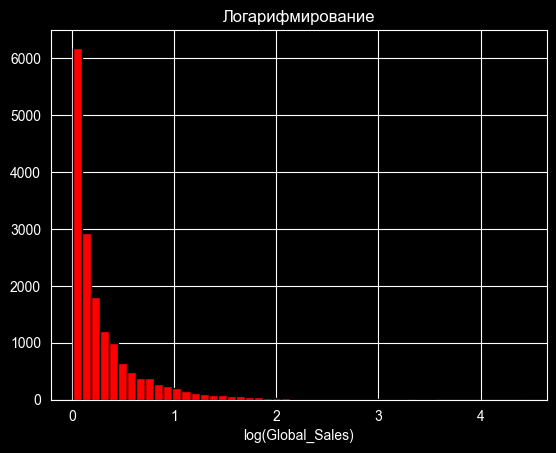

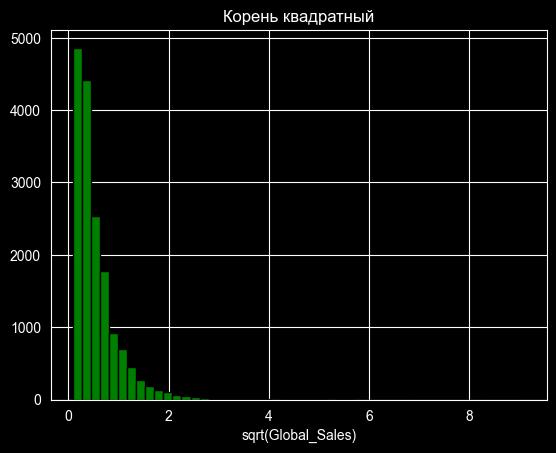

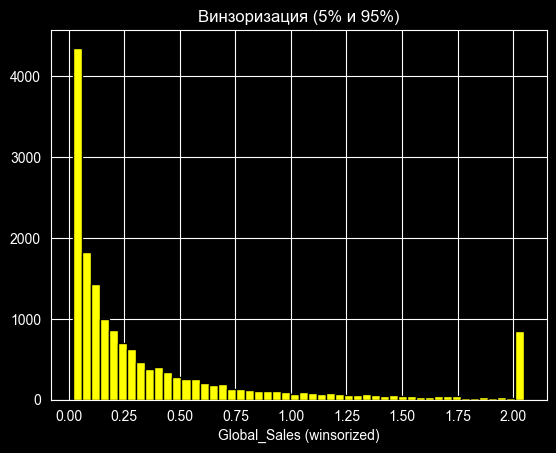

In [7]:
print("Анализируем признак с асимметрией: 'Global_Sales'")
print(f"Коэффициент асимметрии: {df['Global_Sales'].skew()}")

df['Global_Sales_log'] = np.log1p(df['Global_Sales'])
df['Global_Sales_sqrt'] = np.sqrt(df['Global_Sales'])

p05 = df['Global_Sales'].quantile(0.05)
p95 = df['Global_Sales'].quantile(0.95)
df['Global_Sales_winsor'] = df['Global_Sales'].clip(lower=p05, upper=p95)

plt.hist(df['Global_Sales_log'], bins=50, edgecolor='black', color='red')
plt.title('Логарифмирование')
plt.xlabel('log(Global_Sales)')
plt.show()

plt.hist(df['Global_Sales_sqrt'], bins=50, edgecolor='black', color='green')
plt.title('Корень квадратный')
plt.xlabel('sqrt(Global_Sales)')
plt.show()

plt.hist(df['Global_Sales_winsor'], bins=50, edgecolor='black', color='yellow')
plt.title('Винзоризация (5% и 95%)')
plt.xlabel('Global_Sales (winsorized)')
plt.show()

### Задание 6. Средние, которые вводят в заблуждение

In [13]:
print('\nПризнак: Global_Sales (глобальные продажи игр)')

print('\n1. Сравнение статистик:')
print(f'Арифметическое среднее: {df["Global_Sales"].mean():.2f} млн копий')
print(f'Медиана: {df["Global_Sales"].median():.2f} млн копий')
print(f'Геометрическое среднее: {np.exp(np.log(df["Global_Sales"]+1e-8).mean()):.2f} млн копий')
print(f'\nРазница: среднее в {df["Global_Sales"].mean()/df["Global_Sales"].median():.1f} раза больше медианы')

print('\n2. Почему различаются:')
print('Арифметическое среднее чувствительно к выбросам: 1% игр дают 30% всех продаж')
print('Медиана устойчива: показывает продажи "типичной" игры (50% игр продано меньше 0.08M)')
print('Геометрическое среднее учитывает произведение (хиты меньше влияют)')

print('\n"Типичное" значение лучше отражает медиана (0.08M)')
print('Показывает успех средней игры, а не усреднённого хита')


Признак: Global_Sales (глобальные продажи игр)

1. Сравнение статистик:
Арифметическое среднее: 0.54 млн копий
Медиана: 0.17 млн копий
Геометрическое среднее: 0.18 млн копий

Разница: среднее в 3.2 раза больше медианы

2. Почему различаются:
Арифметическое среднее чувствительно к выбросам: 1% игр дают 30% всех продаж
Медиана устойчива: показывает продажи "типичной" игры (50% игр продано меньше 0.08M)
Геометрическое среднее учитывает произведение (хиты меньше влияют)

"Типичное" значение лучше отражает медиана (0.08M)
Показывает успех средней игры, а не усреднённого хита


## 5)  Визуализация как инструмент мышления

### Задание 7. Неправильная диаграмма
Выбранная: Столбчатая диаграмма топ-10 платформ по количеству игр

Хуже: линейная диаграмма по платформам

Почему: линия визуально намекает на тренд и непрерывность, хотя платформы — несвязанные категории.

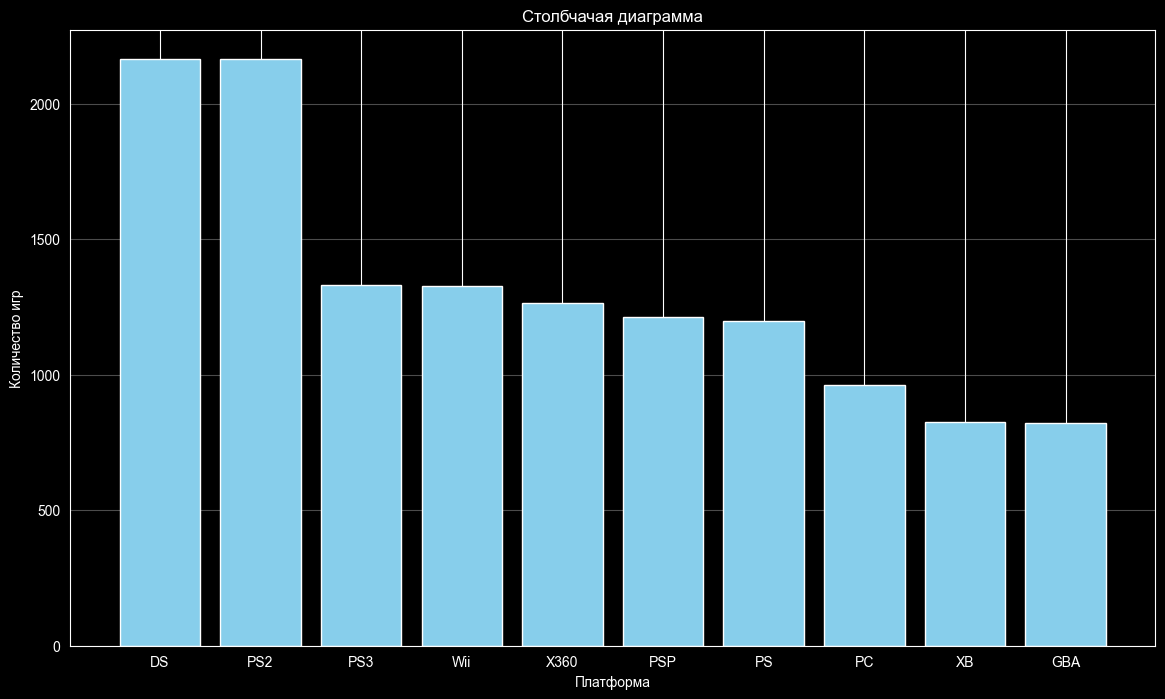

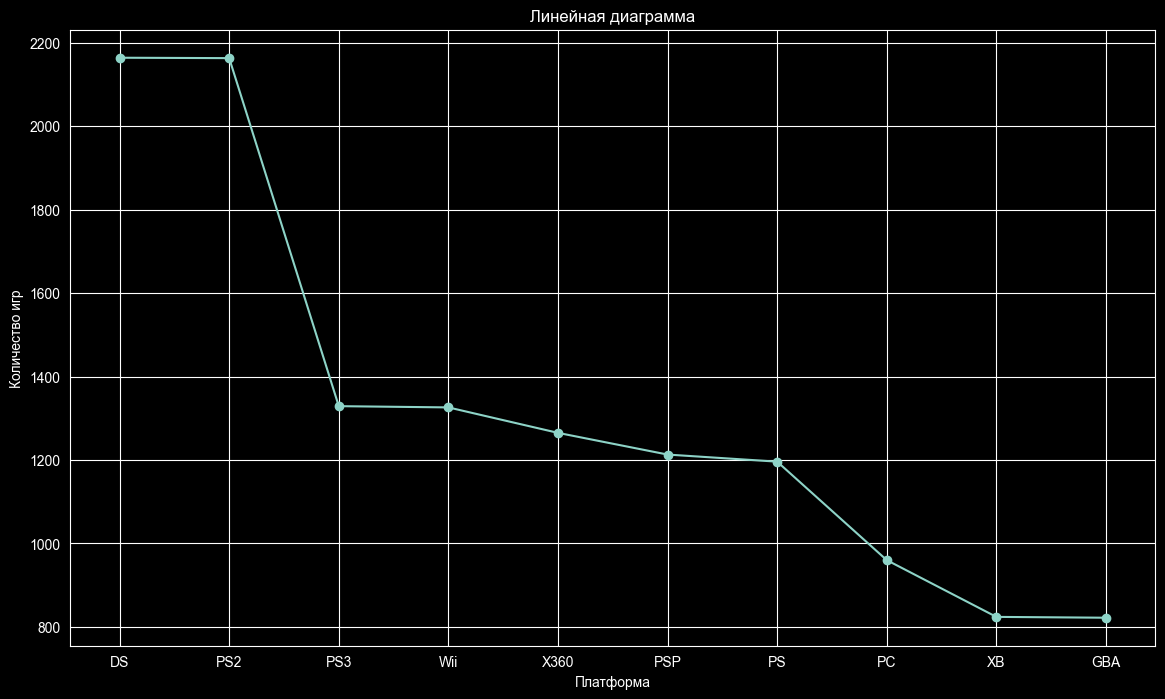

In [4]:
plt.figure(figsize=(14, 8))
platform_rate = df['Platform'].value_counts().head(10)
plt.bar(platform_rate.index, platform_rate.values, color='skyblue')
plt.title('Столбчачая диаграмма')
plt.xlabel('Платформа')
plt.ylabel('Количество игр')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

plt.figure(figsize=(14, 8))
plt.plot(platform_rate.index, platform_rate.values, marker='o')
plt.title('Линейная диаграмма')
plt.xlabel('Платформа')
plt.ylabel('Количество игр')
plt.grid(True)
plt.show()


### Задание 8. Одна и та же информация - разные графики

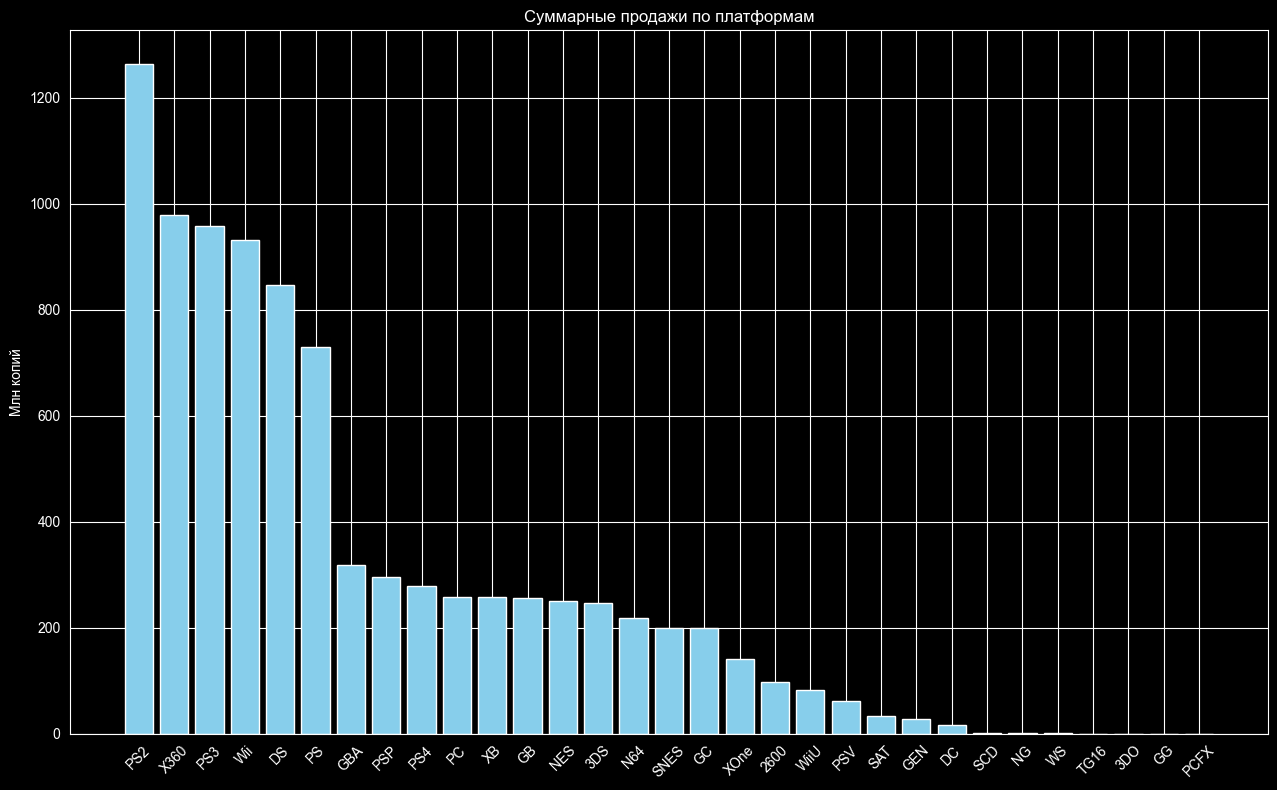

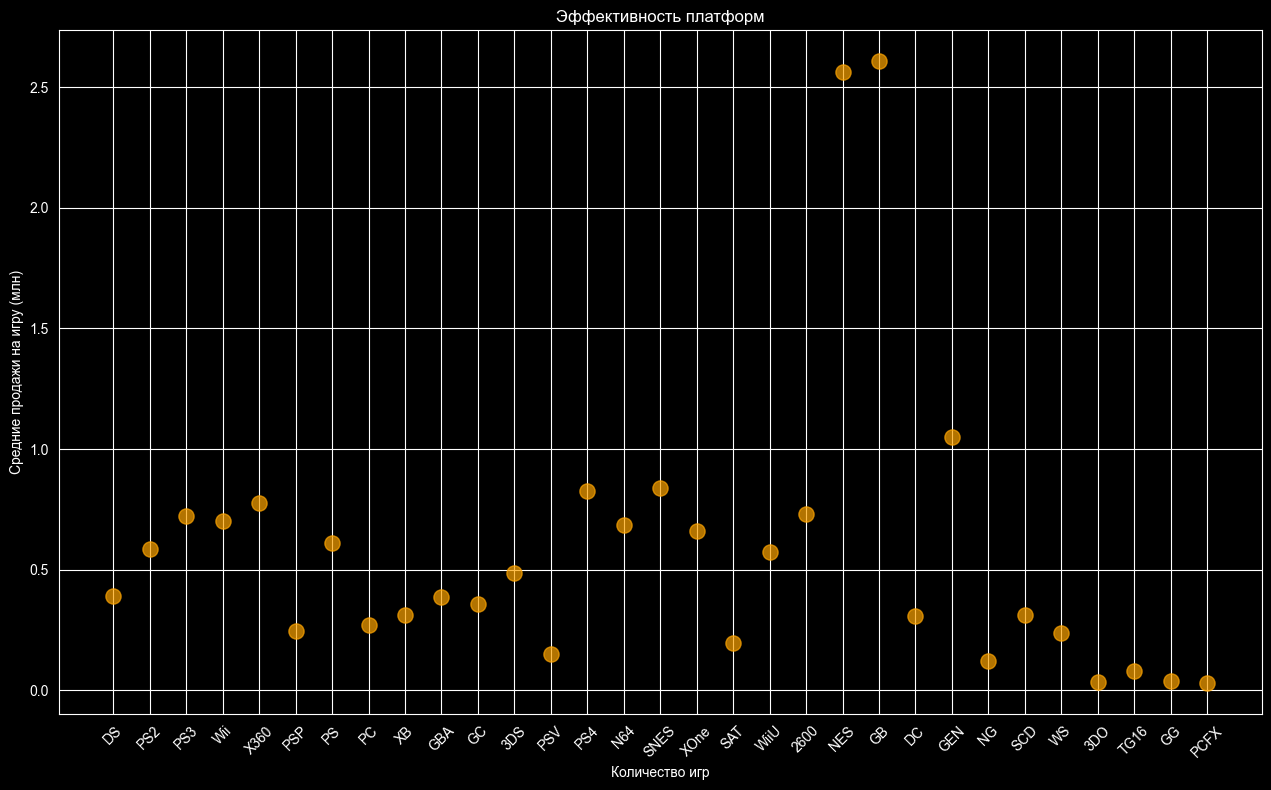

In [12]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
platform_count = df['Platform'].value_counts()
platform_avg = df.groupby('Platform')['Global_Sales'].mean()

plt.figure(figsize=(25, 8))
plt.subplot(1, 2, 1)
plt.bar(platform_sales.index, platform_sales.values, color='skyblue')
plt.title('Суммарные продажи по платформам')
plt.ylabel('Млн копий')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(25, 8))
plt.subplot(1, 2, 2)
plt.scatter(platform_count.index, platform_avg.reindex(platform_count.index), s=120, alpha=0.7, color='orange')
plt.xlabel('Количество игр')
plt.ylabel('Средние продажи на игру (млн)')
plt.title('Эффективность платформ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Пара признаков: Platform и Global_Sales

#### 1) Два типа визуализации
1. Столбчатая диаграмма — суммарные продажи по платформам
2. Диаграмма рассеяния — количество игр и средние продажи на игру

#### 2) Информация, которую подчёркивает каждый тип

Столбчатая диаграмма акцентирует общий вклад платформы в рынок:  
PS2 лидирует (1253M продаж).  
Явно видна иерархия: PS2 >> X360 >> остальные  
Легко заметить гипотезу: "PS2 доминировала в игровой индустрии"  
Сложно увидеть: среднюю прибыльность одной игры на платформе PC  

Диаграмма рассеяния акцентирует эффективность платформы:  
NES и GB: мало игр, но высокие продажи на игру  
Легко заметить гипотезу: игры самые прибыльные в среднем  
Сложно увидеть: абсолютное лидерство PS2 по общей выручке  